# Feature Relationships & Interaction EDA
In this section, we explore the relationships between emotions and their impact on the target mood variable. The main goal is to identify the most informative features, test the data for multicollinearity, and prepare the groundwork for machine learning model selection.

## 1. Environment setup and data loading
We load the necessary libraries for analysis, statistical tests, and dataset preparation.

In [179]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from daily_flow.analytics.datasets.constants import FINAL_DATASET_PERIODS, DatasetPeriod
from daily_flow.analytics.datasets.loader import load_mood_mart_sync
from daily_flow.analytics.datasets.prepare import prepare_public_mood_df
from daily_flow.analytics.datasets.schema import MOOD_COLUMNS
from daily_flow.analytics.datasets.segmentation import (
    add_sub_segments,
    filter_short_sub_segments,
    segment_df,
    slice_periods,
)

#### Dataset preparation
We use a synchronous loader to obtain current data and perform time series segmentation to filter short intervals.

In [180]:
raw_df = load_mood_mart_sync()
df = prepare_public_mood_df(raw_df)

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Users\myros\AppData\Local\Programs\Python\Python311\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x0000025D4ADD3AC0> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-1185' coro=<_async_in_context.<locals>.run_in_context() done, defined at D:\DS-Projects\daily-flow\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-1186' coro=<Kernel.shell_main() running at D:\DS-Projects\daily-flow\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at D:\DS-Projects\daily-flow\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
D:\DS-Projects\daily-flow\.venv\Lib\site-packages\pandas\core\flags.py:53: RuntimeWarning: coroutine 'Kerne

In [181]:
df, segmented = segment_df(df)
df = add_sub_segments(df, max_gap_days=5)
filtered_df, small_mask = filter_short_sub_segments(df, min_days=7, keep_first=True)
filtered_df, resegmented = segment_df(filtered_df)

dfs = slice_periods(filtered_df, FINAL_DATASET_PERIODS)

## 2. Correlation analiz (Feature-to-Feature)
Before analyzing the impact on the target, it is necessary to check how emotions correlate with each other. This will help to avoid duplication of information and identify "groups" of emotions that move synchronously.

### 2.1. Spearman Correlation Matrix
We prepare the data for visualization by cutting off the duplicate upper triangular part of the matrix.

In [182]:
moods_corr_matrix = df[MOOD_COLUMNS].corr(method="spearman").round(4)
upper_tri_mask = np.triu(np.ones_like(moods_corr_matrix, dtype=bool))

### 2.2. Heatmap visualization
Visualizing relationships. We are interested in both strong positive relationships (e.g. Joy + Energy) and negative relationships (e.g. Joy + Sadness).

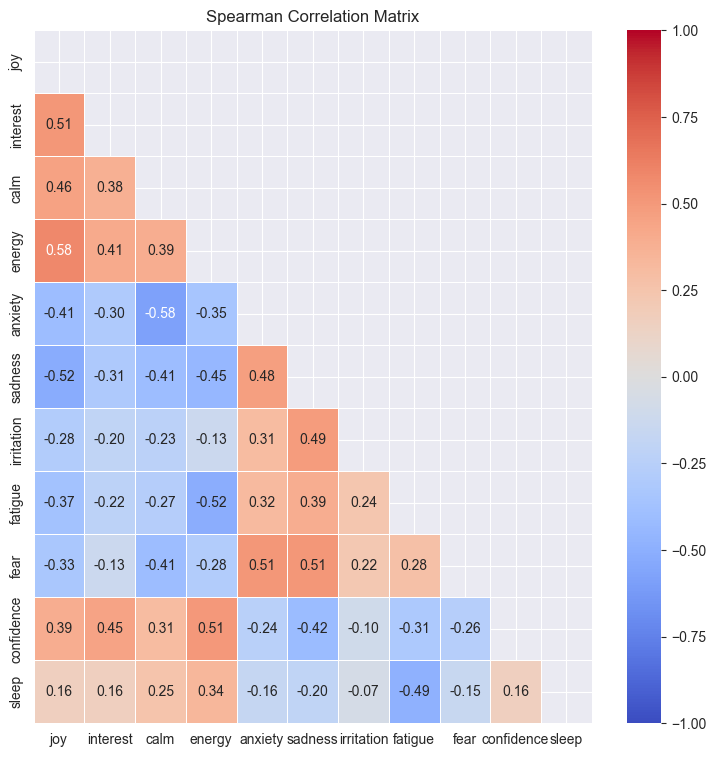

In [183]:
f, ax = plt.subplots(figsize=(9, 9))

sns.heatmap(
    moods_corr_matrix,
    mask=upper_tri_mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Spearman Correlation Matrix")
plt.show()

### 2.3. Pair segmentation by connection strength
We break all emotion pairs into categories: from "duplicates" (which can harm the model) to "noise".

In [184]:
lower_corr = moods_corr_matrix.where(np.tril(np.ones(moods_corr_matrix.shape), k=-1).astype(bool))

pairs = lower_corr.stack().reset_index()
pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

abs_corr = pairs["Correlation"].abs()
conditions = [(abs_corr > 0.9), (abs_corr > 0.7), (abs_corr > 0.4), (abs_corr > 0.2)]

values = ["Duplicates", "Strong Signal", "Noticeable Signal", "Weak Signal"]

pairs["Verdict"] = np.select(conditions, values, default="Noise")

poss_corr = pairs[pairs["Correlation"] > 0].sort_values(by="Correlation", ascending=False)
neg_corr = pairs[pairs["Correlation"] < 0].sort_values(by="Correlation")

display(poss_corr[:10])
display(poss_corr[-5:])
display(neg_corr[:10])
display(neg_corr[-5:])

,Feature 1,Feature 2,Correlation,Verdict
3,energy,joy,0.5823,Noticeable Signal
33,fear,sadness,0.5131,Noticeable Signal
32,fear,anxiety,0.5116,Noticeable Signal
0,interest,joy,0.5086,Noticeable Signal
39,confidence,energy,0.5062,Noticeable Signal
20,irritation,sadness,0.4855,Noticeable Signal
14,sadness,anxiety,0.4762,Noticeable Signal
1,calm,joy,0.4550,Noticeable Signal
37,confidence,interest,0.4498,Noticeable Signal
4,energy,interest,0.4137,Noticeable Signal


,Feature 1,Feature 2,Correlation,Verdict
27,fatigue,irritation,0.2387,Weak Signal
34,fear,irritation,0.2230,Weak Signal
54,sleep,confidence,0.1585,Noise
46,sleep,interest,0.1577,Noise
45,sleep,joy,0.1563,Noise


,Feature 1,Feature 2,Correlation,Verdict
8,anxiety,calm,-0.5820,Noticeable Signal
10,sadness,joy,-0.5216,Noticeable Signal
24,fatigue,energy,-0.5156,Noticeable Signal
52,sleep,fatigue,-0.4858,Noticeable Signal
13,sadness,energy,-0.4471,Noticeable Signal
41,confidence,sadness,-0.4176,Noticeable Signal
12,sadness,calm,-0.4128,Noticeable Signal
6,anxiety,joy,-0.4090,Noticeable Signal
30,fear,calm,-0.4071,Noticeable Signal
21,fatigue,joy,-0.3712,Weak Signal


,Feature 1,Feature 2,Correlation,Verdict
53,sleep,fear,-0.1547,Noise
18,irritation,energy,-0.1298,Noise
29,fear,interest,-0.1269,Noise
42,confidence,irritation,-0.0989,Noise
51,sleep,irritation,-0.0693,Noise


Based on the calculated Spearman correlation matrix and visual analysis of distributions, the following conclusions were drawn regarding the feature structure for the future model:

#### 1. Feature interdependence and redundancy
* **Absence of critical correlation:** The maximum Spearman correlation is 0.58 (pair `anxiety` / `calm`). Since there are no values > 0.8 - 0.9 in the dataset, each feature carries a unique signal and is not a direct duplicate of another.
* **Solution:** No features are removed at this stage. The full dataset (11 features) is passed to the Stage 1 model to preserve maximum informativeness.

#### 2. Key signal clusters
* **The "Stability Seesaw" (Anxiety vs Calm):** The strongest negative relationship -0.58 is found. This pair of features forms the "framework" of the emotional state. Tree-based models (e.g. Random Forest) can effectively exploit this antagonism to identify polar mood states.
* **Negative Affect Cluster:** The features `Fear`, `Anxiety` and `Sadness` show a moderate positive correlation (0.47 - 0.51). They act as a single block of predictors of the "depressive/negative" background.
* **Joy vs Interest 0.51:** The moderate correlation confirms that the state of work "flow/interest" is not always identical to the emotional "joy". This is a critical gap for identifying productive but emotionally neutral days.

#### 3. The role of physical factors
* **Sleep as a foundation of the resource:** `Sleep` has a weak direct correlation with emotional state, but demonstrates a moderate dependence on `Fatigue` -0.49 and `Energy` 0.34.
* **Modeling strategy:** Sleep acts as a "fundamental" feature. It does not predict mood directly at the moment, but explains the physical state of the user, which is the basis for forming the emotional background.

#### 4. Final verdict for ML Stage 1
* **Data quality:** The dataset demonstrates balanced relationships without anomalous distortions.
* **Algorithm selection:** Due to the presence of nonlinear dependencies and the absence of critical correlation, ensemble models (**Random Forest**, **XGBoost**) are preferred. They are able to automatically process feature interaction without the need for manual design of new features at the initial stage.

## 3. Multicollinearity Diagnostics (VIF Analysis)
After analyzing pairwise correlations, it is necessary to check the **group dependence** of the features. Even if the pairwise correlations are moderate, a combination of several features may duplicate another. For this, we use the **VIF (Variance Inflation Factor)** indicator.

### 3.1. Data preparation and cleaning
Since the dataset contains technical rows without emotional ratings (related to logging features in certain periods), we delete records where all emotions are `NaN`. We fill the remaining single gaps with the median, which is safe given the small percentage of such values (studied in EDA 01/02).

In [185]:
df_cleaned = df.dropna(subset=MOOD_COLUMNS, how="all")

X = df_cleaned[MOOD_COLUMNS].copy()

X = X.fillna(X.median()).round().astype(int)

X_with_const = add_constant(X)

In [186]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i)
    for i in range(len(X_with_const.columns))
    if X_with_const.columns[i] != "const"
]
display(vif_data.sort_values("VIF", ascending=False))

,feature,VIF
5,sadness,2.561749
3,energy,2.193368
0,joy,2.151912
7,fatigue,1.924626
4,anxiety,1.855040
2,calm,1.847987
8,fear,1.797553
9,confidence,1.627088
1,interest,1.615940
6,irritation,1.417677


VIF Analysis: Multicollinearity Check

At this stage, a mathematical check of the stability of the future model is carried out using the **VIF (Variance Inflation Factor)** indicator.

#### 1. Mathematical Validation
VIF determines how much the variance of each feature is "inflated" due to its linear relationship with other predictors in the data set.

* **Value range (Range):** 1.36 — 2.56.
* **Maximum VIF:** `sadness` (2.56).
* **Minimum VIF:** `sleep` (1.36) and `irritation` (1.41).

#### 2. Conclusions for Modeling
* **Independence Confirmed:** Since all values are significantly lower than the generally accepted threshold of **5.0**, we confirm the absence of critical multicollinearity. This ensures the stability of the weights (coefficients) and their interpretability in future models.
* **Feature Retention:** None of the features are redundant. Each emotion (even those that showed moderate pairwise correlation on the Heatmap) contains a unique portion of the signal that cannot be fully reconstructed through other features.
* **Model Selection:** A low VIF level gives the "green light" to use a wide range of algorithms: from linear models (Logistic Regression) to ensembles of trees (Random Forest, XGBoost), without fear of biasing the estimates due to excessive feature dependence.

#### 3. Statistical Insight
* **The smallest VIF indicator in the `sleep` feature (1.36):** confirms the previous hypothesis: sleep is the most independent factor in the current dataset. It stands "separately" from the emotional background, which makes it a valuable autonomous predictor that describes the user's physical resource regardless of his momentary emotional reactions.
* **Sadness as an “emotional hub” (VIF 2.56):** The highest score for sadness indicates that it is the most interconnected emotion. Sadness rarely occurs autonomously; it usually entails a decrease in energy and an increase in anxiety, acting as a central node of negative states.
* **Joy & Energy (VIF ~2.15):** The moderately elevated VIF of these features confirms their work in a close duo. In the dataset, joy is almost always accompanied by a surge of strength, which makes them a stable but partially interchangeable marker of good mood.

## 4. Visualizing the distribution of features (Target Interaction Analysis)
To gain a deep understanding of how each emotion separates the classes of the target variable (`common_mood_log`), we use a combination of **Boxplots** (for statistical indicators) and **Stripplots** (for visualizing the density of real data).

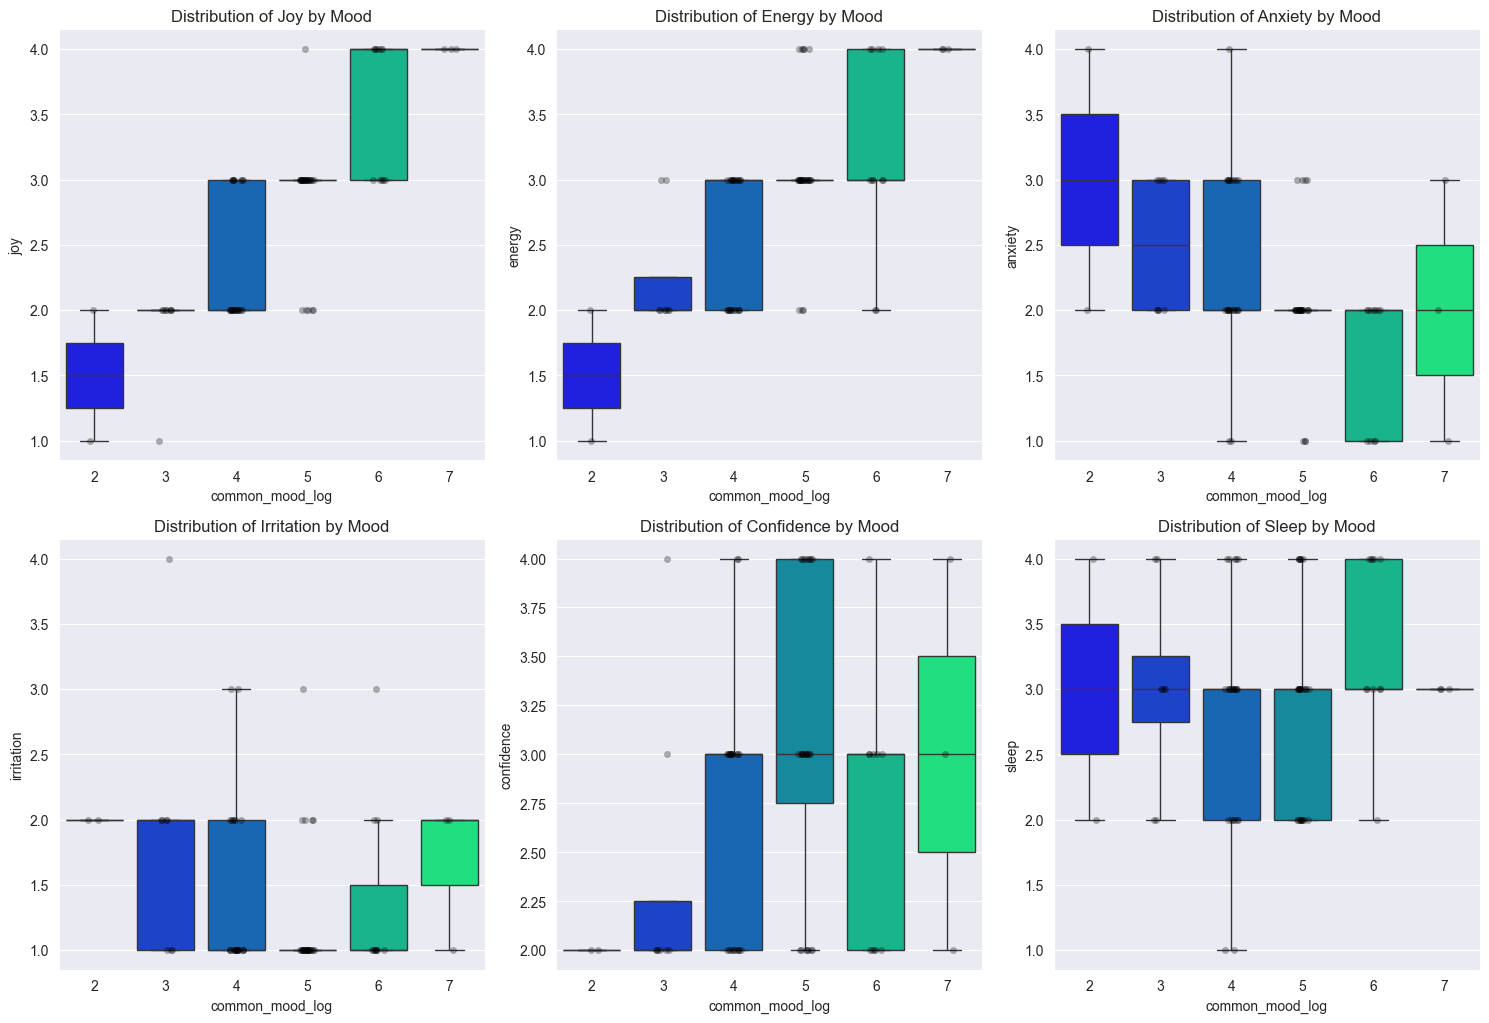

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = ["joy", "energy", "anxiety", "irritation", "confidence", "sleep"]

plt.figure(figsize=(15, 15))
for i, col in enumerate(top_features):
    plt.subplot(3, 3, i + 1)

    sns.boxplot(
        x="common_mood_log",
        y=col,
        data=df,
        palette="winter",
        showfliers=False,
        hue="common_mood_log",
        legend=False,
    )

    sns.stripplot(x="common_mood_log", y=col, data=df, color="black", alpha=0.3, jitter=True)
    plt.title(f"Distribution of {col.capitalize()} by Mood")

plt.tight_layout()

Conclusions of visual distribution analysis

Based on the analysis of the interaction of features with the target variable (`common_mood_log`), key observations for the architecture of the future model were formed:

#### 1. Linear favorites: Joy & Energy
These features have the highest resolution and clear signal.
* **Observation:** A clear linear relationship is observed: medians and interquartile ranges (boxplot body) grow synchronously with mood, almost without crossing between neighboring classes.
* **Feature:** The absence of "whiskers" and "body" at certain levels (3, 5, 7) indicates a high concentration of data - at these points the emotion values are maximally stable.
* **For the model:** These are ideal predictors for any algorithm. Linear models (e.g., logistic regression) are able to effectively interpret this data 100%.

#### 2. Nonlinear and unstable: Anxiety & Confidence
These features demonstrate a more complex relationship that requires flexible modeling algorithms.
* **Anxiety:** The feature is nonlinear. The decrease in anxiety stops at mood 6, and at the peak (level 7) it increases again. This may indicate a state of "excited euphoria". Due to the significant overlap between levels 3 and 4, anxiety alone is not sufficient to distinguish them.
* **Confidence:** At low mood levels (2-3), the data is concentrated (confidence is consistently low). However, as mood increases, high variability appears - significant scatter and long "whiskers" on the graphs.
* **Insight:** High confidence does not guarantee a good mood, but its absence is almost always a marker of a low emotional background.

#### 3. Weak Signals and Noise: Irritation & Sleep
* **Irritation:** The static median across all levels suggests that Irritation works more like a binary trigger (present/absent) than a gradient scale. It is weak as a stand-alone feature, but can be useful in combination with others.
* **Sleep:** Recognized as the most difficult feature for today-to-today forecasting. Medians and percentiles overlap heavily across all mood classes. The high standard deviation (STD) makes this feature too noisy for direct linear modeling.

#### What does this mean for modeling?

1. **Algorithm Priority:** Due to the nonlinearity of `Anxiety` and the high variance of `Confidence`, tree-based models (**Random Forest**, **XGBoost**) will have a significant advantage over linear ones. They are able to create complex interaction rules (for example: *"if Joy is high AND Anxiety is increasing - it is mood 7"*).
2. **Problem of distinguishing classes 3-4:** Most features (except Joy/Energy) have identical distributions for these levels. It will be difficult for the model to differentiate them, so the `sadness` feature or additional Feature Engineering will be required.
3. **Outlier processing:** The minimum number of outliers in key features (for example, in `Joy`) allows you to abandon aggressive data cleaning, while preserving the natural variability of states.

## 5. Mutual Information (MI) Assessment
To conclude the analysis, we use the **Mutual Information (MI)** metric. It measures the share of information we obtain about the mood (`common_mood_log`), knowing the value of a specific emotion. Unlike correlation, MI is able to capture complex nonlinear relationships.

### 5.1. Calculation of MI Scores

To ensure correct calculation, we fill in single gaps with the median and indicate to the algorithm that our features are discrete (scores 1-4).

In [188]:
X = dfs[DatasetPeriod.FULL][MOOD_COLUMNS].copy()
X = X.fillna(X.median()).round().astype(int)

y = dfs[DatasetPeriod.FULL]["common_mood_log"].dropna()

mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_results = pd.Series(mi_scores, index=MOOD_COLUMNS).sort_values(ascending=False)

print("Mutual Information Scores:")
print(mi_results)

Mutual Information Scores:
joy           0.502401
sadness       0.339096
energy        0.314153
interest      0.289337
fatigue       0.189938
anxiety       0.170749
calm          0.162366
fear          0.143375
irritation    0.125699
sleep         0.104664
confidence    0.096249
dtype: float64


Mutual Information Analysis: Feature Importance

The final stage of feature analysis used the `mutual_info_classif` algorithm to estimate the individual information contribution of each emotion to predicting the target variable (`common_mood_log`). Unlike correlation, MI takes into account any type of dependencies, including complex nonlinear relationships.

#### 1. Information Gain Ranking
* **Top Predictors (Model Core):** `joy` (0.50), `sadness` (0.33), `energy` (0.31). These features have the highest resolution for determining mood.
* **Middle Tier (Important Context):** `interest` (0.28), `fatigue` (0.19), `anxiety` (0.17).
* **Low Signal (Noise Candidates):** `sleep`, `confidence`, `irritation` (<0.12).

#### 2. Hidden Insights
* **Joy dominance:** The `joy` indicator is 1.5 times higher than `sadness` and almost 5 times higher than `confidence`. This confirms that the final mood (`common_mood_log`) for the user is primarily an emotional valence (positive/negative), and not an assessment of one's own effectiveness or confidence.
* **Fatigue-Energy asymmetry:** While `energy` has a high MI (0.31), `fatigue` (fatigue) lags significantly behind (0.19). **Analytical conclusion:** The presence of energy is a much clearer marker of a good day than its absence. The state of `fatigue` can be characteristic of both a neutral and a bad day, making it a less specific predictor.
* **Sleep Paradox:** The low `sleep` indicator (0.10) indicates that the amount of sleep does not directly affect mood "day to day". This creates a promising hypothesis for the next stage of analysis (**Time Series EDA**): sleep probably affects emotional state with a lag of 1-2 days.
* **Anxiety-Calm Mirror:** The features `anxiety` (0.17) and `calm` (0.16) have almost identical contributions. This confirms that they work as complementary predictors: the absence of anxiety almost automatically means a state of calm. Their combination increases the model's confidence in predicting a "stable" day.

#### 3. Modeling Strategy (Implications for Modeling)
* **Potential of Nonlinear Models:** High MI values at moderate linear correlations (which we saw in the Heatmap) indicate that tree-based models (**Random Forest**, **XGBoost**) will show a significantly better result than linear regression.
* **Feature Engineering (Binarization):** For low signal features where data is clustered around a single value (e.g. `irritation`, `fear`), it is advisable to test the creation of binary features (e.g. `is_irritated` 0/1). This can turn a "noisy" metric into a clear trigger for the algorithm.
* **Dimensionality Preservation:** Since even the weakest features have MI > 0.09, it is advisable to keep the entire feature set at this stage. In conditions of limited data, every piece of information is valuable for training the Stage 1 model.

### Technical Summary: EDA Phase 03 (Feature Engineering & Validation)

This report summarizes the results of the statistical analysis of feature vectors for the **DailyFlow** project and justifies the chosen 3-stage modeling architecture.

---

#### 1. Feature Interdependence & Multicollinearity
A Spearman correlation analysis and variance inflation factor (VIF) calculation were performed to assess the stability of the feature matrix X.

* **No redundancy:** The maximum correlation of 0.58 and VIF values ​​in the range [1.36, 2.56] confirm the absence of critical multicollinearity.
* **Solution:** The full set of 11 features was retained. Each feature contributes a unique signal, minimizing the risk of overfitting due to duplicate predictors.
* **Central Nodes:** `Sadness` (VIF 2.56) is identified as the central hub of negative affect, while `Sleep` (VIF 1.36) is the most autonomous external feature.

#### 2. Signal Resolution & Distribution Analysis
Analysis of the interaction of features with the target label (`common_mood_log`) using Boxplots and Stripplots revealed the following:

* **High-Resolution Linear Signals:** The features `Joy` and `Energy` demonstrate clear linear class separability. This provides high classification accuracy at polar values ​​of the Target (High/Low mood).
* **Non-linear Dynamics:** `Anxiety` and `Confidence` have nonlinear patterns (in particular, the increase in anxiety at peak mood values ​​- "excited euphoria").
* **Low Signal Triggers:** `Irritation` and `Fear` work as binary triggers. To increase their significance in Stage 3, binarization (`is_irritated`) is planned.

#### 3. Information Gain (Mutual Information)
The use of `mutual_info_classif` allowed us to identify hidden dependencies that are not accessible to linear correlation:

* **Feature Importance:** `Joy` (0.50) and `Sadness` (0.33) form the information core.
* **Asymmetry Insight:** An asymmetry was detected between `Energy` (MI 0.31) and `Fatigue` (MI 0.19). The presence of energy is a stronger predictor of the state than its absence.
* **The Sleep Paradox:** The low instantaneous MI of sleep (0.10) confirms the architectural hypothesis of using sleep as a lag feature (T-1) in Stage 3.

---
#### 4. Machine Learning Roadmap & Architecture

###### Stage 1 (The Teacher): Emotions → Mood Reconstruction
* **Model:** Ensemble (XGBoost / Random Forest).
* **Rationale:** Due to the nonlinearity of key features and complex interaction effects, tree-based models will have an advantage over linear approximators.

##### Stage 2 (Pseudo-labeling): Dataset Augmentation
* **Goal:** Reconstruct Y_{pseudo} for periods with missing labels.
* **Validation:** Low VIF guarantees the stability of M1 weights, allowing for reliable pseudo-labels for time series augmentation.

##### Stage 3 (The Student): Time-Series Forecasting
* **Input:** X: [Mood_{T-1}, Sleep_{T}, Rolling\_Avg_{T-1}, Weekday].
* **Strategy:** Taking into account emotional inertia and the lag effect of physical factors (sleep) detected during EDA.
* **Evaluation:** Final testing on the "Gold Standard" data segment (where Y is verified).

---
**Verdict:** Dataset validated, feature vectors optimized. Moving on to EDA 4.